# Check DATA_FIKS

Baca `Datalog/DATA_FIKS.xlsx` (log Misc / dashboard 15 kolom + ENU/ECEF).

In [4]:
from pathlib import Path
import pandas as pd

root = Path(r"D:\Pengujian\Ship_Model_Control_ESP32-S3 v2026.01")
xlsx = root / "Datalog" / "DATA_FIKS.xlsx"

df = pd.read_excel(xlsx, sheet_name="Sheet1")
print(xlsx)
print("baris, kolom:", df.shape)
print("kolom:", list(df.columns))
df.head()

D:\Pengujian\Ship_Model_Control_ESP32-S3 v2026.01\Datalog\DATA_FIKS.xlsx
baris, kolom: (382, 24)
kolom: ['timestamp', 'latitude', 'longitude', 'speedMps', 'Calc_deg_servo_1', 'Calc_deg_servo_2', 'roll', 'pitch', 'yaw', 'zigzag_yaw', 'rpm_prop_1', 'rpm_prop_2', 'battery_1', 'battery_2', 'mode_auto', 'x_enu_flat', 'y_enu_flat', 'z_enu_flat', 'X_ecef', 'Y_ecef', 'Z_ecef', 'x_enu_ecef', 'y_enu_ecef', 'z_enu_ecef']


,timestamp,latitude,longitude,speedMps,Calc_deg_servo_1,Calc_deg_servo_2,roll,pitch,yaw,zigzag_yaw,...,mode_auto,x_enu_flat,y_enu_flat,z_enu_flat,X_ecef,Y_ecef,Z_ecef,x_enu_ecef,y_enu_ecef,z_enu_ecef
0,1993.731,-7.287184,112.796194,0.15,-40.00,-39.93,5.13,0.18,324.99,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
1,1993.831,-7.287184,112.796194,0.20,-40.06,-40.11,5.14,0.18,324.87,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
2,1993.931,-7.287184,112.796194,0.13,-40.41,-40.17,5.15,0.19,324.78,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
3,1994.031,-7.287184,112.796194,0.16,-39.94,-39.87,5.15,0.21,324.73,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0
4,1994.131,-7.287184,112.796194,0.18,-40.24,-40.47,5.15,0.24,324.73,0,...,0,0.0,0.0,0,-2.451408e+06,5.832755e+06,-803647.745115,-0.0,0.0,0.0


In [5]:
df.info()
df[["timestamp", "latitude", "longitude", "speedMps", "yaw", "mode_auto"]].describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 382 entries, 0 to 381
Data columns (total 24 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   timestamp         382 non-null    float64
 1   latitude          382 non-null    float64
 2   longitude         382 non-null    float64
 3   speedMps          382 non-null    float64
 4   Calc_deg_servo_1  382 non-null    float64
 5   Calc_deg_servo_2  382 non-null    float64
 6   roll              382 non-null    float64
 7   pitch             382 non-null    float64
 8   yaw               382 non-null    float64
 9   zigzag_yaw        382 non-null    int64  
 10  rpm_prop_1        382 non-null    int64  
 11  rpm_prop_2        382 non-null    int64  
 12  battery_1         382 non-null    float64
 13  battery_2         382 non-null    float64
 14  mode_auto         382 non-null    int64  
 15  x_enu_flat        382 non-null    float64
 16  y_enu_flat        382 non-null    float64
 1

,timestamp,latitude,longitude,speedMps,yaw,mode_auto
count,382.000000,382.000000,382.000000,382.000000,382.000000,382.000000
mean,2012.887283,-7.287173,112.796127,0.611440,160.963063,0.727749
std,11.160892,0.000013,0.000032,0.140706,131.267766,0.445702
min,1993.731000,-7.287188,112.796088,0.130000,0.020000,0.000000
25%,2003.256000,-7.287183,112.796102,0.550000,20.520000,0.000000
50%,2012.781000,-7.287178,112.796120,0.610000,142.195000,1.000000
75%,2022.606000,-7.287163,112.796150,0.700000,304.400000,1.000000
max,2032.131000,-7.287147,112.796194,0.920000,359.100000,1.000000


Yaw di file ini sudah 0–360 (bukan −180…180). Konvensi HWT905 setelah wrap Remote/Send: **0 = Utara, 270 ≈ Timur, 90 ≈ Barat**.

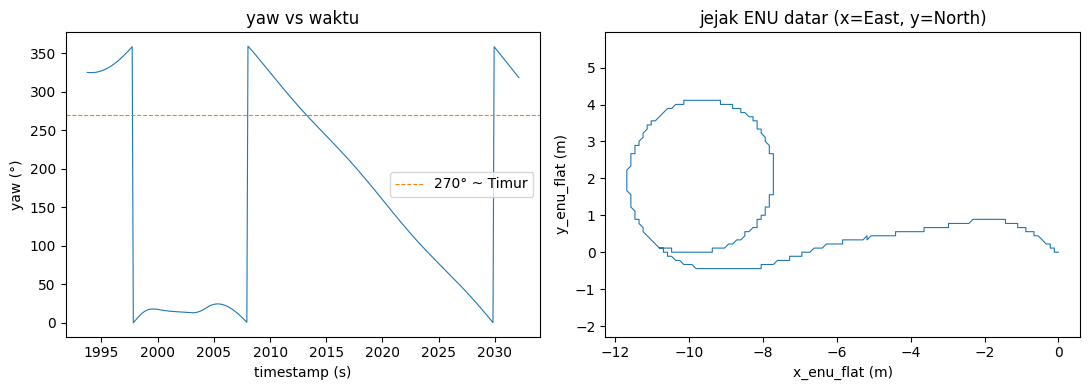

In [6]:
import matplotlib.pyplot as plt

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df["timestamp"], df["yaw"], lw=0.8)
ax[0].set_title("yaw vs waktu")
ax[0].set_xlabel("timestamp (s)")
ax[0].set_ylabel("yaw (°)")
ax[0].axhline(270, color="C1", ls="--", lw=0.8, label="270° ~ Timur")
ax[0].legend()

ax[1].plot(df["x_enu_flat"], df["y_enu_flat"], lw=0.8)
ax[1].set_title("jejak ENU datar (x=East, y=North)")
ax[1].set_xlabel("x_enu_flat (m)")
ax[1].set_ylabel("y_enu_flat (m)")
ax[1].axis("equal")
fig.tight_layout()
plt.show()

Bandingkan ENU datar rumus 1.2 / Remote (`R = 6 371 000` m) dengan kolom `x_enu_flat`, `y_enu_flat`.

Origin = baris pertama file: **lat0 = −7.287184**, **lon0 = 112.796194**.

```text
x = (lon − lon0) × (π/180) × R × cos(lat0)   // East
y = (lat − lat0) × (π/180) × R                 // North
```

origin lat0=-7.287184  lon0=112.796194
RMSE x  0.000000 m   max |dx| 0.000000 m
RMSE y  0.000000 m   max |dy| 0.000000 m


,timestamp,latitude,longitude,x_calc,x_enu_flat,dx_enu,y_calc,y_enu_flat,dy_enu
0,1993.731,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
1,1993.831,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
2,1993.931,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
3,1994.031,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
4,1994.131,-7.287184,112.796194,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000e+00
5,1994.231,-7.287184,112.796193,-0.110297,-0.110297,1.387779e-17,0.000000,0.000000,0.000000e+00
6,1994.331,-7.287183,112.796193,-0.110297,-0.110297,1.387779e-17,0.111195,0.111195,3.330669e-16
7,1994.431,-7.287183,112.796193,-0.110297,-0.110297,1.387779e-17,0.111195,0.111195,3.330669e-16


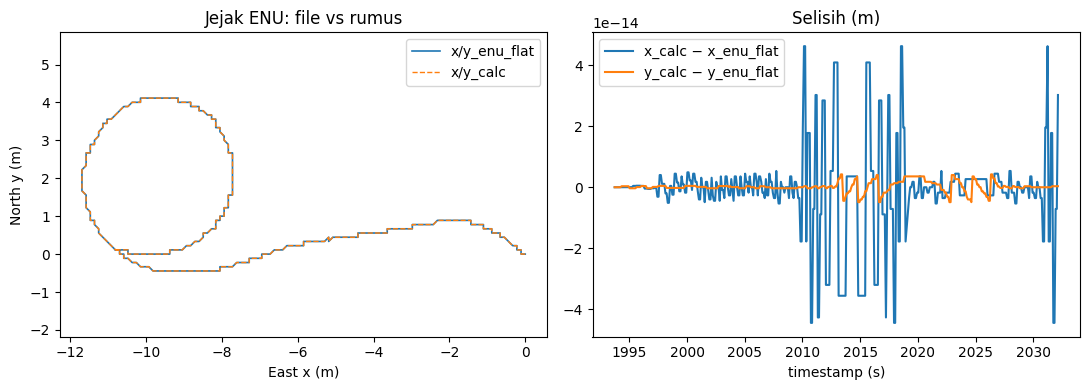

In [7]:
import numpy as np

R = 6_371_000.0
lat0 = float(df.iloc[0]["latitude"])   # -7.287184
lon0 = float(df.iloc[0]["longitude"])  # 112.796194
lat0_rad = np.deg2rad(lat0)

df["x_calc"] = np.deg2rad(df["longitude"] - lon0) * R * np.cos(lat0_rad)
df["y_calc"] = np.deg2rad(df["latitude"] - lat0) * R
df["dx_enu"] = df["x_calc"] - df["x_enu_flat"]
df["dy_enu"] = df["y_calc"] - df["y_enu_flat"]

print(f"origin lat0={lat0:.6f}  lon0={lon0:.6f}")
print(f"RMSE x  {np.sqrt(np.mean(df['dx_enu']**2)):.6f} m   max |dx| {df['dx_enu'].abs().max():.6f} m")
print(f"RMSE y  {np.sqrt(np.mean(df['dy_enu']**2)):.6f} m   max |dy| {df['dy_enu'].abs().max():.6f} m")

display(df[["timestamp", "latitude", "longitude", "x_calc", "x_enu_flat", "dx_enu", "y_calc", "y_enu_flat", "dy_enu"]].head(8))

fig, ax = plt.subplots(1, 2, figsize=(11, 4))
ax[0].plot(df["x_enu_flat"], df["y_enu_flat"], label="x/y_enu_flat", lw=1.2)
ax[0].plot(df["x_calc"], df["y_calc"], "--", label="x/y_calc", lw=1.0)
ax[0].set_title("Jejak ENU: file vs rumus")
ax[0].set_xlabel("East x (m)")
ax[0].set_ylabel("North y (m)")
ax[0].axis("equal")
ax[0].legend()

ax[1].plot(df["timestamp"], df["dx_enu"], label="x_calc − x_enu_flat")
ax[1].plot(df["timestamp"], df["dy_enu"], label="y_calc − y_enu_flat")
ax[1].set_title("Selisih (m)")
ax[1].set_xlabel("timestamp (s)")
ax[1].legend()
fig.tight_layout()
plt.show()